<a href="https://colab.research.google.com/github/murtazaarsh7/ml_in_summers2026/blob/main/Copy_of_Churn_model_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import kagglehub
import os

# Download the dataset. This will return the path to the downloaded dataset's root directory.
dataset_dir = kagglehub.dataset_download('shrutimechlearn/churn-modelling')

# Construct the full path to the CSV file within the downloaded dataset directory.
# Assuming 'Churn_Modelling.csv' is directly inside the dataset_dir.
csv_file_path = os.path.join(dataset_dir, 'Churn_Modelling.csv')

df = pd.read_csv(csv_file_path)

Using Colab cache for faster access to the 'churn-modelling' dataset.


In [3]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
df=df.drop(columns=["RowNumber","CustomerId","Surname"])

In [5]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


In [9]:
df['Geography'].value_counts()

,count
Geography,
France,5014
Germany,2509
Spain,2477


In [10]:
df['Gender'].value_counts()

,count
Gender,
Male,5457
Female,4543


In [11]:
df=pd.get_dummies(df,columns=["Geography","Gender"],drop_first=True).astype(int)

In [12]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,1,0
2,502,42,8,159660,3,1,0,113931,1,0,0,0
3,699,39,1,0,2,0,0,93826,0,0,0,0
4,850,43,2,125510,1,1,1,79084,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0,2,1,0,96270,0,0,0,1
9996,516,35,10,57369,1,1,1,101699,0,0,0,1
9997,709,36,7,0,1,0,1,42085,1,0,0,0
9998,772,42,3,75075,2,1,0,92888,1,1,0,1


In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x=df.drop(columns=["Exited"])
y=df["Exited"]
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=1)

In [15]:
x_train.shape

(8000, 11)

In [16]:
y_test.shape

(2000,)

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler=StandardScaler()

In [19]:
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.fit_transform(x_test)

In [20]:
x_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model=Sequential()
model.add(Dense(11,activation="relu",input_dim=11))
model.add(Dense(11,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

In [ ]:
model.summary()

In [ ]:
model.compile(loss="binary_crossentropy",optimizer='Adam',metrics=["accuracy"])

In [25]:
history=model.fit(x_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7663 - loss: 0.5405 - val_accuracy: 0.7975 - val_loss: 0.4769
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7972 - loss: 0.4598 - val_accuracy: 0.7975 - val_loss: 0.4501
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7972 - loss: 0.4426 - val_accuracy: 0.7975 - val_loss: 0.4397
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7972 - loss: 0.4352 - val_accuracy: 0.7975 - val_loss: 0.4340
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7978 - loss: 0.4297 - val_accuracy: 0.7975 - val_loss: 0.4302
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8006 - loss: 0.4259 - val_accuracy: 0.7987 - val_loss: 0.4258
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8078 - loss: 0.4218 - val_accuracy: 0.8056 - val_loss: 0.4227
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8181 - loss: 0.4177 - val_accu

In [26]:
model.layers[0].get_weights()

[array([[ 0.16008762,  0.01265234,  0.17353065, -0.3399343 , -0.00677114,
          0.01929858, -0.07726637, -0.27721632,  0.2795434 ,  0.41917902,
         -0.16948602],
        [-0.08795883, -0.04913688,  0.1920811 , -0.261649  ,  0.80267817,
          0.1602063 , -0.7041598 ,  0.8008525 , -0.07794902, -0.6444404 ,
          1.2227081 ],
        [-0.13517293, -0.0434047 ,  0.32636052,  0.10309755,  0.13091284,
          0.00459828,  0.06321124,  0.36971828, -0.07387226, -0.4314905 ,
         -0.01191365],
        [-0.5239465 ,  0.39153025,  0.12021049,  0.07992093, -0.00707555,
         -0.28527173,  0.18520913,  0.10638672, -0.41607928,  0.21747483,
         -0.22057119],
        [ 0.36201277,  1.216948  ,  0.99364793,  0.4475344 ,  0.50437236,
         -0.30270895,  0.22738072,  0.36714426,  1.026498  ,  0.33923686,
         -0.34832966],
        [ 0.15412532, -0.04613057, -0.23068203, -0.05039331,  0.13046695,
         -0.15430723,  0.09918474,  0.14289255, -0.3321025 , -0.2760404

In [27]:
model.layers[1].get_weights()

[array([[ 0.54189396, -0.06769823, -0.04389596,  0.40997592,  0.7289787 ,
          0.4871479 ,  0.37391976,  0.35480025, -0.17729807, -0.12129778,
          0.2762889 ],
        [ 1.1582708 , -0.78713745, -0.7376539 , -0.8890736 , -0.5074201 ,
         -0.46643645, -2.1668124 , -0.658772  , -0.80253845, -0.711661  ,
         -0.2879542 ],
        [ 1.1021887 ,  0.34558815,  0.21820664,  0.11516916,  0.3555564 ,
          0.27000016, -0.5353959 ,  0.1110094 , -0.37098268, -0.38141605,
         -0.08190507],
        [ 0.62172055, -0.678619  ,  0.01971489,  0.35624096, -0.06347871,
          0.83882105,  0.09402345,  0.36057252,  0.52731335,  0.31916252,
          0.1362817 ],
        [ 0.09517825,  0.6238872 ,  0.4156359 ,  0.30501643, -0.13122179,
         -0.41193894, -0.4672557 , -0.21650201,  0.6651316 , -0.32280385,
          0.34010237],
        [ 0.22546968, -0.03458399,  0.06945052, -0.19218758,  0.10844662,
         -0.28022528,  0.10394809, -0.06168273, -0.00336344,  0.5175771

In [28]:
y_log=model.predict(x_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [29]:
y_predict=np.where(y_log>0.5,1,0)

In [30]:
y_predict

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [31]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_predict)

0.863

In [32]:
import matplotlib.pyplot as plt

In [33]:
history.history

{'accuracy': [0.7662500143051147,
  0.7971875071525574,
  0.7971875071525574,
  0.7971875071525574,
  0.7978125214576721,
  0.8006250262260437,
  0.807812511920929,
  0.8181250095367432,
  0.8246874809265137,
  0.8290625214576721,
  0.83203125,
  0.8340625166893005,
  0.8365625143051147,
  0.8410937786102295,
  0.8451562523841858,
  0.8487499952316284,
  0.8557812571525574,
  0.8557812571525574,
  0.8590624928474426,
  0.8598437309265137,
  0.8598437309265137,
  0.8620312213897705,
  0.8610937595367432,
  0.8629687428474426,
  0.8631250262260437,
  0.8629687428474426,
  0.8642187714576721,
  0.862500011920929,
  0.8637499809265137,
  0.8635937571525574,
  0.8643749952316284,
  0.8623437285423279,
  0.86328125,
  0.8626562356948853,
  0.86328125,
  0.8653125166893005,
  0.862500011920929,
  0.8635937571525574,
  0.8621875047683716,
  0.8651562333106995,
  0.8651562333106995,
  0.864062488079071,
  0.8628125190734863,
  0.86328125,
  0.8629687428474426,
  0.8637499809265137,
  0.86328125

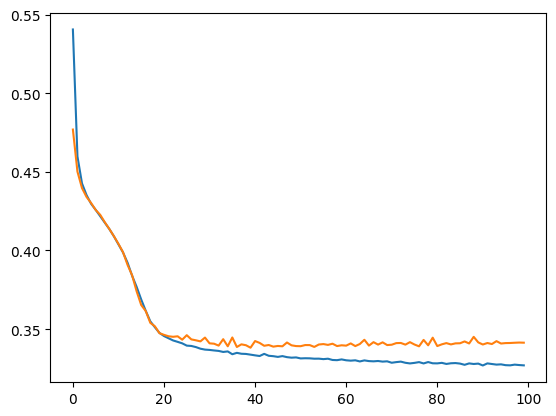

In [34]:
plt.plot(history.history['loss'])
plt.plot(history.history["val_loss"])